<a href="https://colab.research.google.com/github/maazali04/deep-learning-from-scratch/blob/main/01_perceptron_and_single_neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron

- A perceptron is a specific, early type of **artificial neuron**. While every perceptron is an artificial neuron, not all artificial neurons are perceptrons.
- A **perceptron** uses a **strict step function** for a simple yes/no output, whereas **modern artificial neurons** use **smooth, flexible math functions** for complex tasks.
-  It takes input data, multiplies each piece of data by a weight, adds a bias, and uses an activation function (Step function) to make a choice.

<p align="center">
  <img src="https://raw.githubusercontent.com/maazali04/deep-learning-from-scratch/main/images/perceptron.svg" width="500" alt="Perceptron Diagram">
</p>

Where

- Inputs ($x_1, x_2, \dots$): Your incoming data (features).
- Weights ($w_1, w_2, \dots$): How much each input actually matters.
- Bias ($b$): A starting offset so the neuron doesn't always rely on zero inputs.
- Summation ($\sum$): Multiply inputs by their weights and add the bias ($z = w \cdot x + b$).
- Step Function: If $z \ge 0$, output 1. If $z < 0$, output 0.
- Output ($\hat{y}$): The final YES/NO prediction.

## Forward Pass

A forward pass is simply feeding data forward through your neuron to get a prediction.

It is a one-way assembly line:

- Inputs ($x$) go in $\rightarrow$ Raw data entered.
- Neuron does the math $\rightarrow$ Multiplies inputs by weights, adds bias ($z = w \cdot x + b$).
- Activation fires $\rightarrow$ Passes $z$ through the step function.
- Output ($\hat{y}$) comes out $\rightarrow$ The final guess ($0$ or $1$).

> Important: A forward pass only makes a decision. It does not correct mistakes or update weights yet—that happens later during training.

In [ ]:
def perceptron_forward(inputs, weights, bias):
    # 1. Calculate the weighted sum + bias
    z = sum(i * w for i, w in zip(inputs, weights)) + bias
    # 2. Apply the step function
    return 1 if z >= 0 else 0

In [ ]:

dataset = [
    ([0, 0], 0),
    ([0, 1], 0),
    ([1, 0], 0),
    ([1, 1], 1)
]

# Set custom initial weights and bias
weights = [0.5, 0.5]
bias = -0.7

# Run testing loop
print("Testing Forward Pass:\n")
for x, y_true in dataset:
    # STEP 1: Forward pass gets prediction
    y_pred = perceptron_forward(x, weights, bias)

    # STEP 2: Loss/Error calculated AFTER forward pass
    error = y_true - y_pred

    print(f"Input: {x} | True Label: {y_true} | Prediction: {y_pred} | Error: {error}")

Testing Forward Pass:

Input: [0, 0] | True Label: 0 | Prediction: 0 | Error: 0
Input: [0, 1] | True Label: 0 | Prediction: 0 | Error: 0
Input: [1, 0] | True Label: 0 | Prediction: 0 | Error: 0
Input: [1, 1] | True Label: 1 | Prediction: 1 | Error: 0


However, you might wonder how we ensure the weights and biases are accurate for all scenarios if they aren't properly initialized from the start. For this purpose Perceptron uses **Perceptron Learning Rule**.


## Perceptron Learning Rule

The Perceptron Learning Rule is an iterative supervised learning algorithm used to train a perceptron to classify linearly separable binary data.

It consists of the following steps:

1. Calculate Z
$$z=\sum _{i=1}^{n}w_{i}x_{i}+b$$

2. Apply Activation Function (Step)

$$ \hat {y}=\begin{cases}1&\text{if }z\ge 0\\ 0 \text{ (or }-1)&\text{if }z<0\end{cases}$$

3.  Evaluate the Error
$$\text{Error}=y- \hat{y}$$

4. Update Weights and Bias

$$w_{i}^{\text{new}}=w_{i}^{\text{old}}+\alpha \cdot (y-\hat {y})\cdot x_{i}$$
&nbsp;
$$b^{\text{new}}=b^{\text{old}}+\alpha \cdot (y-\hat {y})$$

## Perceptron Convergece Theorem
The Perceptron Convergence Theorem states that if a set of training examples is linearly separable, then the perceptron learning algorithm is guaranteed to converge to a weight vector that correctly classifies all training examples after a finite number of updates.

## Python Implementation of Perceptron



Converged at epoch 4

Learned Parameters:
Final Weights: [0.1 0.1]
Final Bias: -0.10

Model Verification:
Input [0 0] -> Predicted: 0
Input [0 1] -> Predicted: 1
Input [1 0] -> Predicted: 1
Input [1 1] -> Predicted: 1


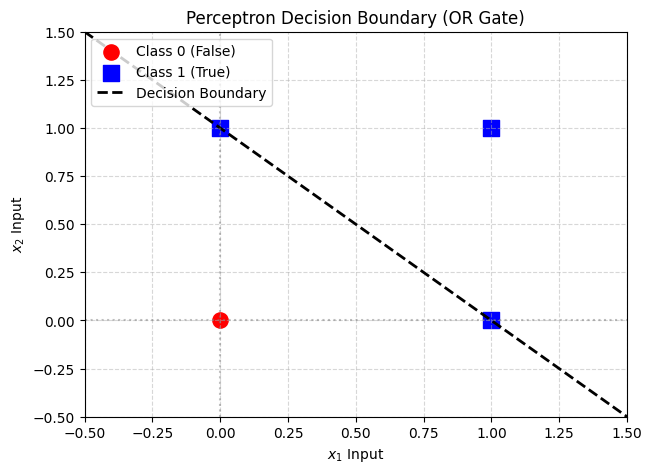

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, num_inputs: int, learning_rate: float = 0.1, epochs: int = 100):
        # Initialize weights to zeros (or small random numbers) and bias to zero
        self.weights = np.zeros(num_inputs)
        self.bias = 0.0
        self.lr = learning_rate
        self.epochs = epochs

    def predict(self, x: np.ndarray) -> int:
        """Forward pass: computes weighted sum and applies Heaviside step function."""
        z = np.dot(x, self.weights) + self.bias
        return 1 if z >= 0 else 0

    def fit(self, X: np.ndarray, y: np.ndarray):
        """Training loop implementing the Perceptron Learning Rule."""
        for epoch in range(self.epochs):
            total_errors = 0

            for i in range(len(X)):
                x_i = X[i]
                y_true = y[i]

                # 1. Forward Pass
                y_pred = self.predict(x_i)

                # 2. Compute Error
                error = y_true - y_pred

                # 3. Parameter Updates (Perceptron Learning Rule)
                if error != 0:
                    self.weights += self.lr * error * x_i
                    self.bias += self.lr * error
                    total_errors += 1

            # Stop early if the model achieves zero classification error
            if total_errors == 0:
                print(f"Converged at epoch {epoch + 1}")
                break

# --- Example Execution (OR Gate) ---
if __name__ == "__main__":
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([0, 1, 1, 1])

    model = Perceptron(num_inputs=2, learning_rate=0.1, epochs=20)
    model.fit(X, y)

    print("\nLearned Parameters:")
    print(f"Final Weights: {model.weights}")
    print(f"Final Bias: {model.bias:.2f}")

    print("\nModel Verification:")
    for inputs in X:
        print(f"Input {inputs} -> Predicted: {model.predict(inputs)}")

    # Plot Setup
    plt.figure(figsize=(7, 5))

    # 1. Scatter plot the dataset points
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', marker='o', s=120, label='Class 0 (False)')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='s', s=120, label='Class 1 (True)')

    # 2. Derive Decision Boundary: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
    x1_vals = np.linspace(-0.5, 1.5, 100)
    w1, w2 = model.weights
    b = model.bias

    if w2 != 0:
        x2_vals = -(w1 * x1_vals + b) / w2
        plt.plot(x1_vals, x2_vals, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

    # 3. Format plot view
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel('$x_1$ Input')
    plt.ylabel('$x_2$ Input')
    plt.title('Perceptron Decision Boundary (OR Gate)')
    plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
    plt.axvline(0, color='gray', linestyle=':', alpha=0.5)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

## Limitation of Perceptron
The fundamental limitation of a single Perceptron is its inability to draw non-linear decision boundaries, making it impossible to solve problems like XOR.

XOR Predictions:
Input: [0 0] | Target: 0 | Predicted: 1 | ✗
Input: [0 1] | Target: 1 | Predicted: 1 | ✓
Input: [1 0] | Target: 1 | Predicted: 0 | ✗
Input: [1 1] | Target: 0 | Predicted: 0 | ✓


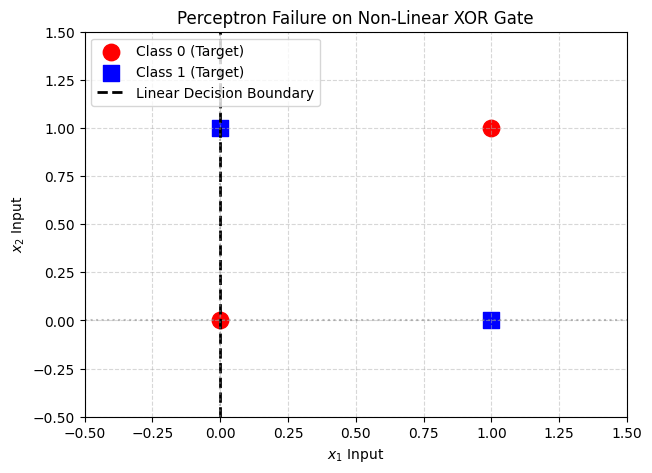

In [ ]:
# 1. XOR Gate Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])  # XOR logic: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0

# 2. Fit existing Perceptron on XOR
model = Perceptron(num_inputs=2, learning_rate=0.1, epochs=100)
model.fit(X, y)

# 3. Print predictions to demonstrate failure
print("XOR Predictions:")
for x_i, y_true in zip(X, y):
    y_pred = model.predict(x_i)
    print(
        f"Input: {x_i} | Target: {y_true} | Predicted: {y_pred} | {'✓' if y_true == y_pred else '✗'}"
    )

# 4. Plot XOR data and the failed decision boundary
plt.figure(figsize=(7, 5))

# Plot target classes
plt.scatter(
    X[y == 0][:, 0],
    X[y == 0][:, 1],
    color="red",
    marker="o",
    s=140,
    label="Class 0 (Target)",
)
plt.scatter(
    X[y == 1][:, 0],
    X[y == 1][:, 1],
    color="blue",
    marker="s",
    s=140,
    label="Class 1 (Target)",
)

# Plot decision boundary line: w1*x1 + w2*x2 + b = 0
x1_vals = np.linspace(-0.5, 1.5, 100)
w1, w2 = model.weights
b = model.bias

if w2 != 0:
    x2_vals = -(w1 * x1_vals + b) / w2
    plt.plot(
        x1_vals,
        x2_vals,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Linear Decision Boundary",
    )
elif w1 != 0:
    plt.axvline(
        x=-b / w1,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Linear Decision Boundary",
    )

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("$x_1$ Input")
plt.ylabel("$x_2$ Input")
plt.title("Perceptron Failure on Non-Linear XOR Gate")
plt.axhline(0, color="gray", linestyle=":", alpha=0.5)
plt.axvline(0, color="gray", linestyle=":", alpha=0.5)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

As you see at even at 100 epochs it didn't converge. Whatever the higher number of epochs you use, it will never converge as Single Perceptron is not supposed to capture non-linear pattern.

## Evolution of the Modern Artificial Neuron

To handle non-linear structures like XOR, a model must combine multiple decision boundaries, requiring a network of connected units. Stacking classical Perceptrons into layers fails because their step function produces zero gradients, making error propagation impossible. Solving this requires transforming the classical Perceptron into a Modern Artificial Neuron.

# Modern Artificial Neuron

The step function acts as a hard switch ($0$ or $1$), creating a flat line with zero slope everywhere except at $z=0$, where it is undefined. Replacing the step function with a smooth, continuous activation function gives the neuron a non-zero derivative ($\frac{d a}{d z}$), unlocking gradient calculations across the network.



## Structure of a Modern Artificial Neuron

A modern neuron processes data in two distinct phases:
- Linear Combination (Pre-Activation $z$):
$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

- Non-Linear Transformation (Post-Activation $a$):
$$a = \sigma(z)$$

Using the Sigmoid function as a classic example:$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

<p align="center">
  <img src="https://raw.githubusercontent.com/maazali04/deep-learning-from-scratch/main/images/Modern%20Neuron.svg" width="500" alt="Perceptron Diagram">
</p>

## Activation Function

While dozens of domain-specific activation functions exist in research, they fall into 4 main categories based on their mathematical behavior and use case:


<table border="1" style="width: 100%; border-collapse: collapse; text-align: left; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="padding: 12px;">Category</th>
      <th style="padding: 12px;">Activation Function</th>
      <th style="padding: 12px;">Formula</th>
      <th style="padding: 12px;">Range</th>
      <th style="padding: 12px;">Key Use Case &amp; Behavior</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="2" style="padding: 12px;"><b>S-Shaped (Classical)</b></td>
      <td style="padding: 12px;"><b>Sigmoid</b></td>
      <td style="padding: 12px;"><i>&sigma;</i>(<i>z</i>) = 1 / (1 + <i>e</i><sup>-<i>z</i></sup>)</td>
      <td style="padding: 12px;">(0, 1)</td>
      <td style="padding: 12px;">Binary classification output layer. Suffers from vanishing gradients.</td>
    </tr>
    <tr>
      <td style="padding: 12px;"><b>Tanh</b></td>
      <td style="padding: 12px;">tanh(<i>z</i>) = (<i>e</i><sup><i>z</i></sup> - <i>e</i><sup>-<i>z</i></sup>) / (<i>e</i><sup><i>z</i></sup> + <i>e</i><sup>-<i>z</i></sup>)</td>
      <td style="padding: 12px;">(-1, 1)</td>
      <td style="padding: 12px;">Zero-centered alternative to Sigmoid; common in older RNN architectures.</td>
    </tr>
    <tr>
      <td rowspan="2" style="padding: 12px;"><b>Piecewise Linear (Standard)</b></td>
      <td style="padding: 12px;"><b>ReLU</b></td>
      <td style="padding: 12px;"><i>f</i>(<i>z</i>) = max(0, <i>z</i>)</td>
      <td style="padding: 12px;">[0, &infin;)</td>
      <td style="padding: 12px;">Default choice for hidden layers. Computationally fast, but can suffer from "Dying ReLU".</td>
    </tr>
    <tr>
      <td style="padding: 12px;"><b>Leaky ReLU</b></td>
      <td style="padding: 12px;"><i>f</i>(<i>z</i>) = max(<i>&alpha;z</i>, <i>z</i>)</td>
      <td style="padding: 12px;">(-&infin;, &infin;)</td>
      <td style="padding: 12px;">Prevents dead neurons by keeping a small slope (<i>&alpha;</i> &approx; 0.01) for negative values.</td>
    </tr>
    <tr>
      <td rowspan="2" style="padding: 12px;"><b>Smooth / Non-Monotonic (Modern)</b></td>
      <td style="padding: 12px;"><b>GELU</b></td>
      <td style="padding: 12px;"><i>f</i>(<i>z</i>) = <i>z</i> &middot; <i>&Phi;</i>(<i>z</i>)</td>
      <td style="padding: 12px;">[-0.17, &infin;)</td>
      <td style="padding: 12px;">Standard in modern Transformer models (BERT, GPT, Vision Transformers).</td>
    </tr>
    <tr>
      <td style="padding: 12px;"><b>Swish / SiLU</b></td>
      <td style="padding: 12px;"><i>f</i>(<i>z</i>) = <i>z</i> &middot; <i>&sigma;</i>(<i>z</i>)</td>
      <td style="padding: 12px;">[-0.28, &infin;)</td>
      <td style="padding: 12px;">Developed by Google; widely used in modern CNNs (EfficientNet).</td>
    </tr>
    <tr>
      <td style="padding: 12px;"><b>Multi-Class Output</b></td>
      <td style="padding: 12px;"><b>Softmax</b></td>
      <td style="padding: 12px;">Softmax(<i>z<sub>i</sub></i>) = <i>e</i><sup><i>z<sub>i</sub></i></sup> / &sum; <i>e</i><sup><i>z<sub>j</sub></i></sup></td>
      <td style="padding: 12px;">(0, 1)</td>
      <td style="padding: 12px;">Converts a vector of logits into a probability distribution that sums to 1.0.</td>
    </tr>
  </tbody>
</table>

- Hidden Layers: ReLU is the standard baseline for simple feedforward networks, while GELU or Swish are preferred for deeper modern architectures.

- Output Layer: Sigmoid for binary classification, Softmax for multi-class classification, and Linear (Identity) for regression problems.


In [ ]:
import numpy as np

class ActivationFunctions:
    @staticmethod
    def sigmoid(z: np.ndarray) -> np.ndarray:
        """Sigmoid activation: 1 / (1 + e^-z)"""
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def tanh(z: np.ndarray) -> np.ndarray:
        """Hyperbolic Tangent activation"""
        return np.tanh(z)

    @staticmethod
    def relu(z: np.ndarray) -> np.ndarray:
        """Rectified Linear Unit: max(0, z)"""
        return np.maximum(0, z)

    @staticmethod
    def leaky_relu(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
        """Leaky ReLU: max(alpha * z, z)"""
        return np.where(z > 0, z, alpha * z)

    @staticmethod
    def swish(z: np.ndarray) -> np.ndarray:
        """Swish/SiLU activation: z * sigmoid(z)"""
        return z * ActivationFunctions.sigmoid(z)

    @staticmethod
    def softmax(z: np.ndarray) -> np.ndarray:
        """Numerically stable Softmax for multi-class outputs."""
        exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

# --- Example Usage ---
if __name__ == "__main__":
    z = np.array([-2.0, -0.5, 0.0, 1.5, 3.0])

    print("Input Vector (z):", z)
    print("Sigmoid:   ", np.round(ActivationFunctions.sigmoid(z), 3))
    print("Tanh:      ", np.round(ActivationFunctions.tanh(z), 3))
    print("ReLU:      ", np.round(ActivationFunctions.relu(z), 3))
    print("Leaky ReLU:", np.round(ActivationFunctions.leaky_relu(z), 3))
    print("Swish:     ", np.round(ActivationFunctions.swish(z), 3))
    print("Softmax:   ", np.round(ActivationFunctions.softmax(z), 3))

Input Vector (z): [-2.  -0.5  0.   1.5  3. ]
Sigmoid:    [0.119 0.378 0.5   0.818 0.953]
Tanh:       [-0.964 -0.462  0.     0.905  0.995]
ReLU:       [0.  0.  0.  1.5 3. ]
Leaky ReLU: [-0.02  -0.005  0.     1.5    3.   ]
Swish:      [-0.238 -0.189  0.     1.226  2.858]
Softmax:    [0.005 0.023 0.038 0.17  0.763]


## Working of a Neuron

Just imagine we want to built a house prediction model. For it a single neuron perform Three steps:



## 1. The Forward Pass: Making a Prediction

The forward pass moves data in one direction—from inputs to output—to compute a prediction. It consists of two sequential steps:
- Weighted Sum ($z$): Multiplies inputs by their weights and adds a bias:$$z = w_1 x_1 + w_2 x_2 + \dots + b = \mathbf{w}^T \mathbf{x} + b$$

- Activation ($a$): Passes the pre-activation $z$ through a linear (in case of regression) or non-linear function (in case of classification and others):

 $$a = z$$
 $$\hat y = a$$

Result: Output $a$ is the estimated house price in dollars.

## 2. Loss Evaluation
Compares prediction $\hat y$ with true target $y$ to quantify total scalar error.
- Calculate error using Mean Squared Error: $L = \frac{1}{2}(\hat y - y)^2$

Note: Different problems may require different loss functions.

|Loss | Formula |
|---|---|
|Mean Squared Error (MSE / L2 Loss) | $$L = \frac{1}{n} \sum (y - \hat{y})^2$$|
|Mean Absolute Error (MAE / L1 Loss)|$$L = \frac{1}{n} \sum \vert{}y - \hat{y}\vert{}$$|
|Binary Cross-Entropy Loss (Log Loss)|$$L = -[y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$$|
|Hinge Loss|$$L = \max(0, 1 - y \cdot \hat{y})$$|


## 3. The Backward Pass: Learning from Errors

The backward pass moves in reverse—from the loss back through the neuron—to answer one question: “How much should we nudge weight $w$ and bias $b$ to make our loss smaller?”

It consists of the following steps:
- Loss Equation = $L = \frac{1}{2}(\hat y - y)^2$
- Output Derivative: $\frac{\partial L}{\partial \hat y} = (\hat y - y)$
- Parameter Gradients: Apply the chain rule:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat y} \cdot \frac{\partial \hat y}{\partial z} \cdot \frac{\partial z}{\partial w} = (\hat y - y) \cdot 1 \cdot x = (\hat y - y)x$$
$$\frac{\partial L}{\partial b} = (\hat y - y) \cdot 1 = (\hat y - y)$$
&nbsp;


## 4. Optimization Step

The optimizer (like SGD or Adam) takes the gradients computed in Step 3 and modifies the actual weights and biases in memory.

- Update Parameters: $w \leftarrow w - \eta \frac{\partial L}{\partial w}$ and $b \leftarrow b - \eta \frac{\partial L}{\partial b}$

## Python Code

### Custom Numpy

In [ ]:
import numpy as np

class SingleNeuron:
    def __init__(self, input_dim: int):
        # Initialize weight and bias
        self.w = np.random.randn(input_dim, 1) * 0.1
        self.b = 0.0

        # Placeholders for intermediate variables and gradients
        self.x = None
        self.z = None
        self.a = None
        self.dw = None
        self.db = None

    # Step 1: Forward Pass (Prediction)
    def forward(self, x: np.ndarray) -> np.ndarray:
        self.x = x
        self.z = np.dot(x, self.w) + self.b
        self.a = self.z  # Linear activation (a = z) for regression
        return self.a

    # Step 2: Loss Evaluation
    @staticmethod
    def compute_loss(a: np.ndarray, y: np.ndarray) -> float:
        # Mean Squared Error: L = (1/2) * mean((a - y)^2)
        return 0.5 * np.mean((a - y) ** 2)

    # Step 3: Backward Pass (Gradient Calculation via Chain Rule)
    def backward(self, y: np.ndarray):
        m = self.x.shape[0]  # Number of samples in batch

        # Derivatives: dL/da = (a - y), da/dz = 1 (linear)
        dL_da = (self.a - y)
        da_dz = 1.0
        dL_dz = dL_da * da_dz

        # Compute gradients wrt parameters
        self.dw = np.dot(self.x.T, dL_dz) / m
        self.db = np.sum(dL_dz) / m

    # Step 4: Optimization Step (Parameter Update)
    def update_params(self, lr: float):
        self.w -= lr * self.dw
        self.b -= lr * self.db


# --- Executing the Pipeline ---
if __name__ == "__main__":
    # House size in 1,000 sq ft (e.g., 1.5 = 1500 sq ft)
    X = np.array([[1.0], [1.5], [2.0], [2.5]])
    # Target house price in $100k (True relationship: price = 2.0 * size + 1.0)
    y = np.array([[3.0], [4.0], [5.0], [6.0]])

    neuron = SingleNeuron(input_dim=1)
    learning_rate = 0.05
    epochs = 100

    print("--- Starting Training Loop ---")
    for epoch in range(epochs):
        # 1. Forward Pass
        predictions = neuron.forward(X)

        # 2. Loss Evaluation
        loss = neuron.compute_loss(predictions, y)

        # 3. Backward Pass
        neuron.backward(y)

        # 4. Optimization Step
        neuron.update_params(learning_rate)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss:.6f} | Weight: {neuron.w[0,0]:.4f} | Bias: {neuron.b:.4f}")

    # Prediction test for a 1,800 sq ft house (X = 1.8)
    sample_house = np.array([[1.8]])
    predicted_price = neuron.forward(sample_house)
    print(f"\nFinal Prediction for 1,800 sq ft house: ${predicted_price[0,0] * 100:.1f}k")

--- Starting Training Loop ---
Epoch  20 | Loss: 0.001115 | Weight: 1.9665 | Bias: 1.0259
Epoch  40 | Loss: 0.000047 | Weight: 1.9831 | Bias: 1.0316
Epoch  60 | Loss: 0.000041 | Weight: 1.9844 | Bias: 1.0295
Epoch  80 | Loss: 0.000035 | Weight: 1.9855 | Bias: 1.0274
Epoch 100 | Loss: 0.000030 | Weight: 1.9865 | Bias: 1.0255

Final Prediction for 1,800 sq ft house: $460.1k


### PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Data setup
X = torch.tensor([[1.0], [1.5], [2.0], [2.5]], dtype=torch.float32)
y = torch.tensor([[3.0], [4.0], [5.0], [6.0]], dtype=torch.float32)

# Single Neuron Model (1 input, 1 output)
model = nn.Linear(in_features=1, out_features=1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

print("--- PyTorch Training Loop ---")
for epoch in range(100):
    # 1. Forward Pass
    predictions = model(X)

    # 2. Loss Evaluation
    loss = criterion(predictions, y)

    # 3. Backward Pass (Clear previous gradients & calculate new ones)
    optimizer.zero_grad()
    loss.backward()

    # 4. Optimization Step
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        w = model.weight.item()
        b = model.bias.item()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.6f} | Weight: {w:.4f} | Bias: {b:.4f}")

# Prediction test for 1,800 sq ft house
test_x = torch.tensor([[1.8]], dtype=torch.float32)
predicted_price = model(test_x).item()
print(f"\nFinal PyTorch Prediction for 1,800 sq ft: ${predicted_price * 100:.1f}k")

--- PyTorch Training Loop ---
Epoch  20 | Loss: 0.000142 | Weight: 2.0205 | Bias: 0.9612
Epoch  40 | Loss: 0.000106 | Weight: 2.0177 | Bias: 0.9665
Epoch  60 | Loss: 0.000079 | Weight: 2.0153 | Bias: 0.9711
Epoch  80 | Loss: 0.000059 | Weight: 2.0133 | Bias: 0.9750
Epoch 100 | Loss: 0.000044 | Weight: 2.0115 | Bias: 0.9784

Final PyTorch Prediction for 1,800 sq ft: $459.9k


### TensorFlow

In [ ]:
import tensorflow as tf
import numpy as np

# Data setup
X = np.array([[1.0], [1.5], [2.0], [2.5]], dtype=np.float32)
y = np.array([[3.0], [4.0], [5.0], [6.0]], dtype=np.float32)

# Single Neuron Model (1 input unit)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

print("\n--- Keras / TensorFlow Training Loop ---")
for epoch in range(100):
    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # 1. Forward Pass
        predictions = model(X, training=True)
        # 2. Loss Evaluation
        loss = loss_fn(y, predictions)

    # 3. Backward Pass (Compute gradients)
    gradients = tape.gradient(loss, model.trainable_variables)

    # 4. Optimization Step
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    if (epoch + 1) % 20 == 0:
        w = model.layers[0].kernel.numpy()[0][0]
        b = model.layers[0].bias.numpy()[0]
        print(f"Epoch {epoch+1:3d} | Loss: {loss.numpy():.6f} | Weight: {w:.4f} | Bias: {b:.4f}")

# Prediction test for 1,800 sq ft house
test_x = np.array([[1.8]], dtype=np.float32)
predicted_price = model.predict(test_x, verbose=0)[0][0]
print(f"\nFinal Keras Prediction for 1,800 sq ft: ${predicted_price * 100:.1f}k")


--- Keras / TensorFlow Training Loop ---
Epoch  20 | Loss: 0.030553 | Weight: 1.6985 | Bias: 1.5689
Epoch  40 | Loss: 0.022825 | Weight: 1.7394 | Bias: 1.4917
Epoch  60 | Loss: 0.017052 | Weight: 1.7748 | Bias: 1.4250
Epoch  80 | Loss: 0.012739 | Weight: 1.8053 | Bias: 1.3674
Epoch 100 | Loss: 0.009517 | Weight: 1.8317 | Bias: 1.3175

Final Keras Prediction for 1,800 sq ft: $461.5k


Even though all three models converged to nearly the exact same house price prediction (~$460k for $1.8$), their final weights and biases differ slightly after 100 epochs due to weight initialization:

- Custom NumPy: Initialized weights from a small Gaussian distribution ($\mathcal{N}(0, 0.01)$) and bias at $0.0$.

- PyTorch (nn.Linear): Uses Kaiming Uniform initialization ($\mathcal{U}(-\sqrt{k}, \sqrt{k})$), starting both weights and biases at non-zero random bounds.

- Keras (Dense): Uses Glorot Uniform (Xavier) for weights and sets initial bias strictly to $0.0$.

Having mastered the single neuron, we've built the ultimate cornerstone of deep learning—stacking these units into a Multi-Layer Perceptron (MLP) is where the real magic happens, empowering us to capture complex, non-linear patterns that a single neuron could never solve on its own.